In [1]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score, precision_score, recall_score

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, GRU, Dense, Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

## Load the dataset

In [5]:
df = pd.read_csv("../data/train.csv/train.csv")
df.head()

,qid,question_text,target
0,00002165364db923c7e6,How did Quebec nationalists see their province...,0
1,000032939017120e6e44,"Do you have an adopted dog, how would you enco...",0
2,0000412ca6e4628ce2cf,Why does velocity affect time? Does velocity a...,0
3,000042bf85aa498cd78e,How did Otto von Guericke used the Magdeburg h...,0
4,0000455dfa3e01eae3af,Can I convert montra helicon D to a mountain b...,0


## Dataset Imformation

In [6]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isnull().sum())

print("\nData types:")
print(df.dtypes)

Shape: (1306122, 3)

Columns:
['qid', 'question_text', 'target']

Missing values:
qid              0
question_text    0
target           0
dtype: int64

Data types:
qid              object
question_text    object
target            int64
dtype: object


## Check the target distribution

In [7]:
print(df["target"].value_counts())

target
0    1225312
1      80810
Name: count, dtype: int64


In [8]:
print(df["target"].value_counts(normalize=True))

target
0    0.93813
1    0.06187
Name: proportion, dtype: float64


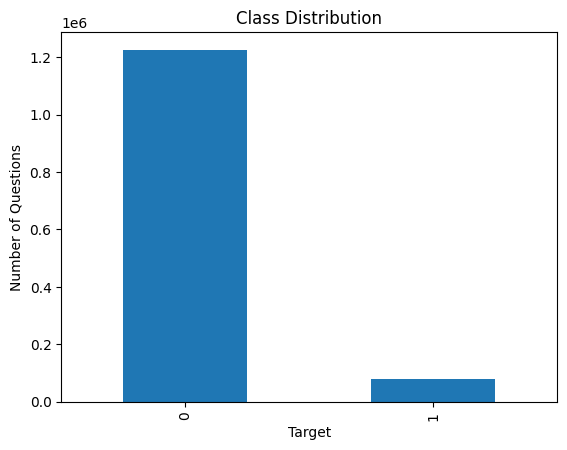

In [10]:
import matplotlib.pyplot as plt

df["target"].value_counts().plot(kind="bar")

plt.xlabel("Target")
plt.ylabel("Number of Questions")
plt.title("Class Distribution")
plt.show()

## Inspect actual questions

In [11]:
print("Sincere questions:\n")

for text in df[df["target"] == 0]["question_text"].head(5):
    print("-", text)

Sincere questions:

- How did Quebec nationalists see their province as a nation in the 1960s?
- Do you have an adopted dog, how would you encourage people to adopt and not shop?
- Why does velocity affect time? Does velocity affect space geometry?
- How did Otto von Guericke used the Magdeburg hemispheres?
- Can I convert montra helicon D to a mountain bike by just changing the tyres?


In [12]:
print("\nInsincere questions:\n")

for text in df[df["target"] == 1]["question_text"].head(5):
    print("-", text)


Insincere questions:

- Has the United States become the largest dictatorship in the world?
- Which babies are more sweeter to their parents? Dark skin babies or light skin babies?
- If blacks support school choice and mandatory sentencing for criminals why don't they vote Republican?
- I am gay boy and I love my cousin (boy). He is sexy, but I dont know what to do. He is hot, and I want to see his di**. What should I do?
- Which races have the smallest penis?


## Check question lengths


In [13]:
df["question_length"] = df["question_text"].astype(str).apply(len)

print(df["question_length"].describe())

count    1.306122e+06
mean     7.067884e+01
std      3.878428e+01
min      1.000000e+00
25%      4.500000e+01
50%      6.000000e+01
75%      8.500000e+01
max      1.017000e+03
Name: question_length, dtype: float64


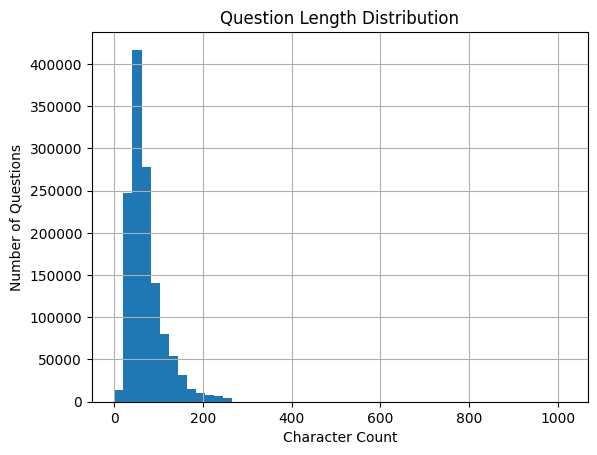

In [14]:
df["question_length"].hist(bins=50)

plt.xlabel("Character Count")
plt.ylabel("Number of Questions")
plt.title("Question Length Distribution")
plt.show()

## Remove unnecessary columns

In [15]:
df = df[["question_text", "target"]].copy()

df.head()

,question_text,target
0,How did Quebec nationalists see their province...,0
1,"Do you have an adopted dog, how would you enco...",0
2,Why does velocity affect time? Does velocity a...,0
3,How did Otto von Guericke used the Magdeburg h...,0
4,Can I convert montra helicon D to a mountain b...,0


## Handle missing text

In [16]:
print(df["question_text"].isnull().sum())

0


In [17]:
df["question_text"] = df["question_text"].fillna("")

In [18]:
print(df["question_text"].isnull().sum())

0


## First development run

In [19]:
df_sample = df.sample(
    n=100000,
    random_state=42
).reset_index(drop=True)

print(df_sample.shape)

(100000, 2)


In [20]:
print(df_sample["target"].value_counts(normalize=True))

target
0    0.93962
1    0.06038
Name: proportion, dtype: float64


In [21]:
df

,question_text,target
0,How did Quebec nationalists see their province...,0
1,"Do you have an adopted dog, how would you enco...",0
2,Why does velocity affect time? Does velocity a...,0
3,How did Otto von Guericke used the Magdeburg h...,0
4,Can I convert montra helicon D to a mountain b...,0
...,...,...
1306117,What other technical skills do you need as a c...,0
1306118,Does MS in ECE have good job prospects in USA ...,0
1306119,Is foam insulation toxic?,0
1306120,How can one start a research project based on ...,0


In [22]:
df_sample

,question_text,target
0,What is the most effective classroom managemen...,0
1,Can I study abroad after 10th class from Bangl...,0
2,How can I make friends as a college junior?,0
3,How do I download free APK Minecraft: Pocket E...,0
4,"Like Kuvera, is ""Groww"" also a free online inv...",0
...,...,...
99995,How do I research list of reliable charcoal im...,0
99996,"What are petroleum products, and what is petro...",0
99997,What are some services that will let you quick...,0
99998,What credit card processors do online marketpl...,0


## Clean the text

In [23]:
import re

def clean_text(text):
    text = str(text).lower()
    
    # Remove HTML tags
    text = re.sub(r"<.*?>", " ", text)
    
    # Remove URLs
    text = re.sub(r"http\S+|www\S+", " ", text)
    
    # Remove extra whitespace
    text = re.sub(r"\s+", " ", text)
    
    return text.strip()

In [24]:
df_sample["clean_text"] = df_sample["question_text"].apply(clean_text)

## Train/validation split

In [25]:
from sklearn.model_selection import train_test_split

X_train_text, X_val_text, y_train, y_val = train_test_split(
    df_sample["clean_text"],
    df_sample["target"],
    test_size=0.2,
    random_state=42,
    stratify=df_sample["target"]
)

In [26]:
print("Training samples:", len(X_train_text))
print("Validation samples:", len(X_val_text))

Training samples: 80000
Validation samples: 20000


In [27]:
print("Training distribution:")
print(y_train.value_counts(normalize=True))

print("\nValidation distribution:")
print(y_val.value_counts(normalize=True))

Training distribution:
target
0    0.939625
1    0.060375
Name: proportion, dtype: float64

Validation distribution:
target
0    0.9396
1    0.0604
Name: proportion, dtype: float64


## Tokenization

In [28]:
from tensorflow.keras.preprocessing.text import Tokenizer

In [29]:
MAX_WORDS = 100000
MAX_LEN = 100

In [30]:
tokenizer = Tokenizer(
    num_words=MAX_WORDS,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(X_train_text)

In [31]:
tokenizer.fit_on_texts(df_sample["clean_text"])

## Convert text to sequences

In [32]:
X_train_seq = tokenizer.texts_to_sequences(X_train_text)
X_val_seq = tokenizer.texts_to_sequences(X_val_text)

In [33]:
print(X_train_text.iloc[0])
print(X_train_seq[0])

ignoring the obvious reasons why we can't do this, but if we somehow got a cup and filled it with one type of bacteria what would it look like?
[4051, 2, 3509, 815, 17, 51, 207, 12, 64, 65, 21, 51, 4308, 251, 5, 1875, 11, 2713, 18, 23, 57, 295, 8, 3100, 3, 37, 18, 215, 43]


## Padding

In [34]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [35]:
X_train = pad_sequences(
    X_train_seq,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

X_val = pad_sequences(
    X_val_seq,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

In [36]:
print("Training shape:", X_train.shape)
print("Validation shape:", X_val.shape)

Training shape: (80000, 100)
Validation shape: (20000, 100)


## Load GloVe

In [42]:
GLOVE_PATH = "../embeddings/glove.6B.100d.txt"

In [43]:
import numpy as np

embeddings_index = {}

with open(GLOVE_PATH, encoding="utf-8") as f:
    for line in f:
        values = line.split()
        word = values[0]
        vector = np.asarray(values[1:], dtype="float32")
        embeddings_index[word] = vector

print("Number of word vectors:", len(embeddings_index))

Number of word vectors: 400000


In [44]:
from pathlib import Path

glove_path = Path("../embeddings/glove.6B.100d.txt")

print("Path:", glove_path.resolve())
print("Exists:", glove_path.exists())

Path: C:\Users\simi\Desktop\zomato-product-analytics\kaggle-competitions\quora-insincere-question-classification\embeddings\glove.6B.100d.txt
Exists: True


## Build the GloVe embedding matrix

In [45]:
word_index = tokenizer.word_index

In [46]:
embedding_dim = 100

embedding_matrix = np.zeros(
    (MAX_WORDS, embedding_dim),
    dtype=np.float32
)

for word, index in word_index.items():

    if index >= MAX_WORDS:
        continue

    embedding_vector = embeddings_index.get(word)

    if embedding_vector is not None:
        embedding_matrix[index] = embedding_vector

print("Embedding matrix shape:", embedding_matrix.shape)

Embedding matrix shape: (100000, 100)


## Check GloVe coverage

In [47]:
covered = 0
considered = 0

for word, index in word_index.items():

    if index >= MAX_WORDS:
        continue

    considered += 1

    if word in embeddings_index:
        covered += 1

coverage = covered / considered

print("Vocabulary considered:", considered)
print("Words covered by GloVe:", covered)
print(f"GloVe coverage: {coverage:.2%}")

Vocabulary considered: 54811
Words covered by GloVe: 41514
GloVe coverage: 75.74%


## Create the embedding layer

In [48]:
import tensorflow as tf

In [49]:
embedding_layer = tf.keras.layers.Embedding(
    input_dim=MAX_WORDS,
    output_dim=embedding_dim,
    weights=[embedding_matrix],
    input_length=MAX_LEN,
    trainable=False
)

c:\Users\simi\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


## Build the BiLSTM

In [50]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout

In [51]:
bilstm_model = Sequential([
    embedding_layer,

    Bidirectional(
        LSTM(64)
    ),

    Dropout(0.3),

    Dense(32, activation="relu"),

    Dropout(0.3),

    Dense(1, activation="sigmoid")
])

In [52]:
bilstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │    10,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,000,000 (38.15 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 10,000,000 (38.15 MB)

## Compile the model

In [53]:
bilstm_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

## Train the BiLSTM

In [54]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [55]:
callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=2,
        restore_best_weights=True
    ),
    ModelCheckpoint(
        "../models/bilstm_best.keras",
        monitor="val_loss",
        save_best_only=True
    )
]

In [56]:
history_bilstm = bilstm_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=5,
    batch_size=256,
    callbacks=callbacks
)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 63s 187ms/step - accuracy: 0.9361 - loss: 0.2370 - precision: 0.3043 - recall: 0.0360 - val_accuracy: 0.9485 - val_loss: 0.1383 - val_precision: 0.6911 - val_recall: 0.2649
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 56s 178ms/step - accuracy: 0.9468 - loss: 0.1436 - precision: 0.6206 - recall: 0.3007 - val_accuracy: 0.9494 - val_loss: 0.1318 - val_precision: 0.7103 - val_recall: 0.2740
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 56s 178ms/step - accuracy: 0.9497 - loss: 0.1341 - precision: 0.6529 - recall: 0.3798 - val_accuracy: 0.9521 - val_loss: 0.1322 - val_precision: 0.6883 - val_recall: 0.3783
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 244s 782ms/step - accuracy: 0.9510 - loss: 0.1261 - precision: 0.6446 - recall: 0.4262 - val_accuracy: 0.9528 - val_loss: 0.1257 - val_precision: 0.6295 - val_recall: 0.5331
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 58s 184ms/step - accuracy: 0.9533 - loss: 0.1245 - precision: 0.6695 - recall: 0.4441 - val_accuracy: 0.9536 - v

## Evaluate the BiLSTM

In [57]:
val_probs_bilstm = bilstm_model.predict(
    X_val,
    batch_size=512
).ravel()

40/40 ━━━━━━━━━━━━━━━━━━━━ 9s 213ms/step


In [58]:
val_preds_bilstm = (val_probs_bilstm >= 0.5).astype(int)

In [59]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)

precision_bilstm = precision_score(y_val, val_preds_bilstm)
recall_bilstm = recall_score(y_val, val_preds_bilstm)
f1_bilstm = f1_score(y_val, val_preds_bilstm)

print("Precision:", precision_bilstm)
print("Recall:", recall_bilstm)
print("F1:", f1_bilstm)

print("\nClassification Report:")
print(classification_report(y_val, val_preds_bilstm))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, val_preds_bilstm))

Precision: 0.6295210166177908
Recall: 0.5331125827814569
F1: 0.5773195876288659

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.98      0.98     18792
           1       0.63      0.53      0.58      1208

    accuracy                           0.95     20000
   macro avg       0.80      0.76      0.78     20000
weighted avg       0.95      0.95      0.95     20000


Confusion Matrix:
[[18413   379]
 [  564   644]]


In [60]:
val_preds_bilstm = (val_probs_bilstm >= 0.5).astype(int)

In [61]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]

for threshold in thresholds:
    preds = (val_probs_bilstm >= threshold).astype(int)

    precision = precision_score(y_val, preds)
    recall = recall_score(y_val, preds)
    f1 = f1_score(y_val, preds)

    print(
        f"Threshold={threshold:.1f} | "
        f"Precision={precision:.3f} | "
        f"Recall={recall:.3f} | "
        f"F1={f1:.3f}"
    )

Threshold=0.2 | Precision=0.445 | Recall=0.762 | F1=0.562
Threshold=0.3 | Precision=0.505 | Recall=0.685 | F1=0.581
Threshold=0.4 | Precision=0.571 | Recall=0.618 | F1=0.593
Threshold=0.5 | Precision=0.630 | Recall=0.533 | F1=0.577
Threshold=0.6 | Precision=0.671 | Recall=0.427 | F1=0.522
Threshold=0.7 | Precision=0.718 | Recall=0.261 | F1=0.383
Threshold=0.8 | Precision=0.754 | Recall=0.079 | F1=0.142


## GRU Model

To compare recurrent architectures, I use a Bidirectional GRU with the
same preprocessing pipeline and pretrained GloVe embeddings used for the
BiLSTM model.

Keeping the input representation and training setup similar allows a more
meaningful comparison between the two recurrent architectures.

In [62]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, GRU, Dense, Dropout

### Bidirectional GRU Architecture

The model uses the pretrained GloVe embedding matrix followed by a
Bidirectional GRU. The recurrent representation is passed through dropout
and dense layers before the final sigmoid classification layer.

In [63]:
gru_model = Sequential([
    Embedding(
        input_dim=MAX_WORDS,
        output_dim=embedding_dim,
        weights=[embedding_matrix],
        input_length=MAX_LEN,
        trainable=False
    ),

    Bidirectional(
        GRU(64)
    ),

    Dropout(0.3),

    Dense(32, activation="relu"),

    Dropout(0.3),

    Dense(1, activation="sigmoid")
])

gru_model.summary()

c:\Users\simi\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │    10,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,000,000 (38.15 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 10,000,000 (38.15 MB)

### Model Compilation

Since this is a binary classification problem, binary cross-entropy is used
as the loss function. Adam is used as the optimizer, while precision and
recall are tracked alongside accuracy because of the class imbalance.

In [64]:
gru_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

### GRU Training

The GRU is trained using the same training and validation splits as the
BiLSTM. Early stopping is used to stop training when validation loss stops
improving, while ModelCheckpoint stores the best-performing model.

In [65]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

callbacks_gru = [
    EarlyStopping(
        monitor="val_loss",
        patience=2,
        restore_best_weights=True
    ),
    ModelCheckpoint(
        "../models/gru_best.keras",
        monitor="val_loss",
        save_best_only=True
    )
]

In [66]:
history_gru = gru_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=5,
    batch_size=256,
    callbacks=callbacks_gru
)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 74s 223ms/step - accuracy: 0.9291 - loss: 0.2331 - precision: 0.2939 - recall: 0.0798 - val_accuracy: 0.9498 - val_loss: 0.1350 - val_precision: 0.6650 - val_recall: 0.3386
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 125s 399ms/step - accuracy: 0.9484 - loss: 0.1389 - precision: 0.6339 - recall: 0.3411 - val_accuracy: 0.9516 - val_loss: 0.1270 - val_precision: 0.6600 - val_recall: 0.4081
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 116s 370ms/step - accuracy: 0.9495 - loss: 0.1318 - precision: 0.6402 - recall: 0.3816 - val_accuracy: 0.9531 - val_loss: 0.1243 - val_precision: 0.6870 - val_recall: 0.4106
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 281s 899ms/step - accuracy: 0.9536 - loss: 0.1235 - precision: 0.6725 - recall: 0.4456 - val_accuracy: 0.9539 - val_loss: 0.1235 - val_precision: 0.7326 - val_recall: 0.3742
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 60s 192ms/step - accuracy: 0.9530 - loss: 0.1215 - precision: 0.6664 - recall: 0.4440 - val_accuracy: 0.9556 -

### Training and Validation Loss

The training history is examined to identify whether the model is learning
effectively and whether there are signs of overfitting.

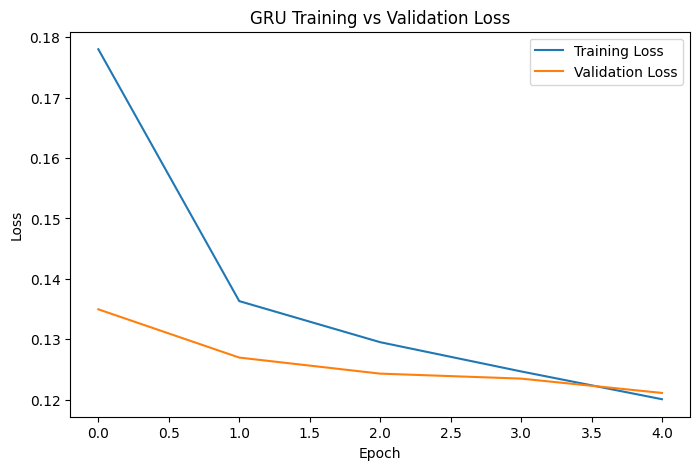

In [67]:
plt.figure(figsize=(8, 5))

plt.plot(history_gru.history["loss"], label="Training Loss")
plt.plot(history_gru.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("GRU Training vs Validation Loss")
plt.legend()
plt.show()

### GRU Evaluation

The trained GRU produces probabilities for the validation samples. A
threshold of 0.5 is initially used to convert probabilities into binary
predictions.

In [69]:
val_probs_gru = gru_model.predict(
    X_val,
    batch_size=512
).ravel()

val_preds_gru = (val_probs_gru >= 0.5).astype(int)

40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 86ms/step


In [70]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

precision_gru = precision_score(y_val, val_preds_gru)
recall_gru = recall_score(y_val, val_preds_gru)
f1_gru = f1_score(y_val, val_preds_gru)

print("Precision:", precision_gru)
print("Recall:", recall_gru)
print("F1:", f1_gru)

print("\nClassification Report:")
print(classification_report(y_val, val_preds_gru))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, val_preds_gru))

Precision: 0.6887573964497041
Recall: 0.4817880794701987
F1: 0.5669751583049196

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98     18792
           1       0.69      0.48      0.57      1208

    accuracy                           0.96     20000
   macro avg       0.83      0.73      0.77     20000
weighted avg       0.95      0.96      0.95     20000


Confusion Matrix:
[[18529   263]
 [  626   582]]


## Threshold Analysis

The sigmoid output represents the predicted probability of the positive
class. A threshold of 0.5 is used initially, but it is not necessarily
optimal for an imbalanced classification problem.

I evaluate multiple thresholds on the validation set to examine the
precision-recall trade-off and identify the threshold that gives the best
validation F1 score.

In [72]:
threshold_results = []

for threshold in np.arange(0.1, 0.91, 0.05):

    preds = (val_probs_gru >= threshold).astype(int)

    precision = precision_score(y_val, preds)
    recall = recall_score(y_val, preds)
    f1 = f1_score(y_val, preds)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df

,Threshold,Precision,Recall,F1
0,0.10,0.371781,0.824503,0.512477
1,0.15,0.431661,0.776490,0.554865
2,0.20,0.477200,0.745033,0.581771
3,0.25,0.522561,0.709437,0.601826
4,0.30,0.557981,0.677152,0.611818
5,0.35,0.598109,0.628311,0.612838
6,0.40,0.624555,0.581126,0.602058
7,0.45,0.662577,0.536424,0.592864
8,0.50,0.688757,0.481788,0.566975
9,0.55,0.709677,0.418874,0.526809


In [73]:
best_threshold_row = threshold_df.loc[
    threshold_df["F1"].idxmax()
]

best_threshold_row

Threshold    0.350000
Precision    0.598109
Recall       0.628311
F1           0.612838
Name: 5, dtype: float64

In [74]:
threshold_results_bilstm = []

for threshold in np.arange(0.10, 0.91, 0.05):

    preds = (val_probs_bilstm >= threshold).astype(int)

    precision = precision_score(y_val, preds)
    recall = recall_score(y_val, preds)
    f1 = f1_score(y_val, preds)

    threshold_results_bilstm.append({
        "Threshold": threshold,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    })

threshold_df_bilstm = pd.DataFrame(threshold_results_bilstm)

threshold_df_bilstm

c:\Users\simi\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,Threshold,Precision,Recall,F1
0,0.10,0.344828,0.827815,0.486855
1,0.15,0.398506,0.794702,0.530827
2,0.20,0.444874,0.761589,0.561661
3,0.25,0.483675,0.723510,0.579768
4,0.30,0.505192,0.684603,0.581371
5,0.35,0.541667,0.656457,0.593563
6,0.40,0.571210,0.617550,0.593477
7,0.45,0.599655,0.575331,0.587241
8,0.50,0.629521,0.533113,0.577320
9,0.55,0.657240,0.480960,0.555449


In [75]:
best_bilstm_threshold = threshold_df_bilstm.loc[
    threshold_df_bilstm["F1"].idxmax()
]

best_bilstm_threshold

Threshold    0.350000
Precision    0.541667
Recall       0.656457
F1           0.593563
Name: 5, dtype: float64

In [76]:
threshold_results_gru = []

for threshold in np.arange(0.10, 0.91, 0.05):

    preds = (val_probs_gru >= threshold).astype(int)

    precision = precision_score(y_val, preds)
    recall = recall_score(y_val, preds)
    f1 = f1_score(y_val, preds)

    threshold_results_gru.append({
        "Threshold": threshold,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    })

threshold_df_gru = pd.DataFrame(threshold_results_gru)

threshold_df_gru.loc[
    threshold_df_gru["F1"].idxmax()
]

Threshold    0.350000
Precision    0.598109
Recall       0.628311
F1           0.612838
Name: 5, dtype: float64

## BiLSTM vs GRU Comparison

Both models use the same cleaned dataset, tokenizer, padded sequences, and
pretrained GloVe embeddings. The primary difference is the recurrent
architecture.

The models are compared using precision, recall, and F1 score, with
particular attention to the minority class because of the strong class
imbalance.

In [71]:
comparison = pd.DataFrame({
    "Model": ["BiLSTM", "BiGRU"],
    "Precision": [precision_bilstm, precision_gru],
    "Recall": [recall_bilstm, recall_gru],
    "F1": [f1_bilstm, f1_gru]
})

comparison

,Model,Precision,Recall,F1
0,BiLSTM,0.629521,0.533113,0.577320
1,BiGRU,0.688757,0.481788,0.566975


## Final Observations

The experiments demonstrate a progression from classical sparse text
representations to pretrained word embeddings and recurrent sequence
models.

The BiLSTM and GRU models use the same GloVe-based input representation,
allowing their performance to be compared primarily on the basis of their
recurrent architectures.

Because the dataset is highly imbalanced, F1, precision, recall, and
confusion-matrix behavior are emphasized rather than accuracy alone.